In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   1439.3 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 2 seconds. 20 already precompiled.


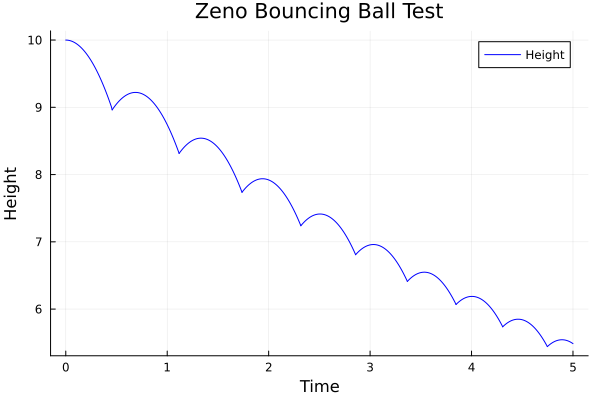

In [ ]:
# Bouncing Ball Parameters
g = 9.81
A = [0.0 1.0; 0.0 0.0]
b = [0.0; -g]

# Guard: x[1] = 0.0 => [1.0, 0.0] ⋅ [x1, x2] + 0.0 = 0
λ = [1.0, 2.0] 
a = 0.0 

# Reset: x1 stays, x2 becomes -0.5*x2
C = [1.0 0.0; 0.0 -0.5] 
κ = [0.0, 0.0]
dir = -1

#Zeno variables as this was originally a zeno test but I used for other things. I was lazy to change them. 
sys_zeno = HD.AffineSystem(A, b, λ, a, C, κ, dir)

prob_zeno = HD.prob(sys_zeno, [10.0, 0.0], (0.0, 5.0))

# Solve
sol_zeno = HD.solve(prob_zeno, HD.RK4(); event_method = HD.LinearLocator())

# Plotting
p_zeno = plt.plot(title="Bouncing Ball Test", xlabel="Time", ylabel="Height", grid=true)
# Note: Ensure split_jumps handles the index alignment correctly
t_zeno, X_zeno = HD.split_jumps(sol_zeno)
plt.plot!(p_zeno, t_zeno, [x[1] for x in X_zeno], color=:blue, label="Height")
plt.display(p_zeno)

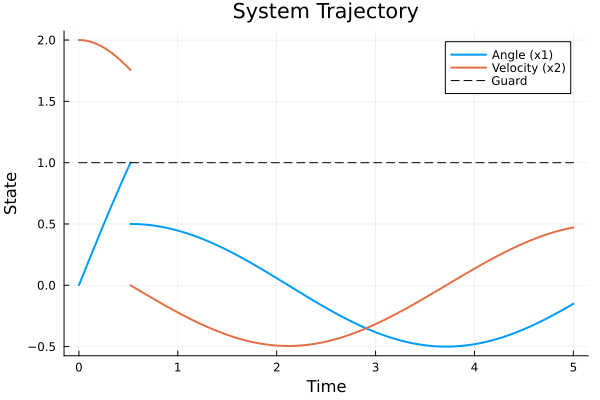

In [3]:
f(x, t) = [x[2], -sin(x[1])] # Simple Pendulum: x1 angle, x2 velocity
h(x) = 1.0 - x[1]            # Guard occurs when angle x1 is 1.0

# Added t=0.0 for signature compatibility
function Δ(x, t=0.0)
    return [0.5, 0.0]
end

sys_gen = HD.GeneralSystem(f, h, Δ)
prob_gen = HD.prob(sys_gen, [0.0, 2.0], (0.0, 5.0))
sol_gen = HD.solve(prob_gen, HD.RK4(); event_method = HD.LinearLocator())

# Use the new universal split_jumps
ts, X_gen = HD.split_jumps(sol_gen)
x1_gen = [x[1] for x in X_gen]
x2_gen = [x[2] for x in X_gen]

guard_line = [1.0 for _ in ts] # Create threshold to plot against time

p_gen = plt.plot(ts, x1_gen, label="Angle (x1)", lw=2, title="System Trajectory", xlabel="Time", ylabel="State")
plt.plot!(p_gen, ts, x2_gen, label="Velocity (x2)", lw=2)
plt.plot!(p_gen, ts, guard_line, label="Guard", linestyle=:dash, color=:black)

plt.display(p_gen)